<a href="https://colab.research.google.com/github/mridulasrinivasula-svg/OPTN-Model/blob/main/BETA_ALL_Tt_and_Dt.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Parameter Estimation Results
----------------------------
Years used: 1995–2025
Beta_all = 2.022236
MSE      = 956707.09
RMSE     = 978.11
R²       = 0.9859


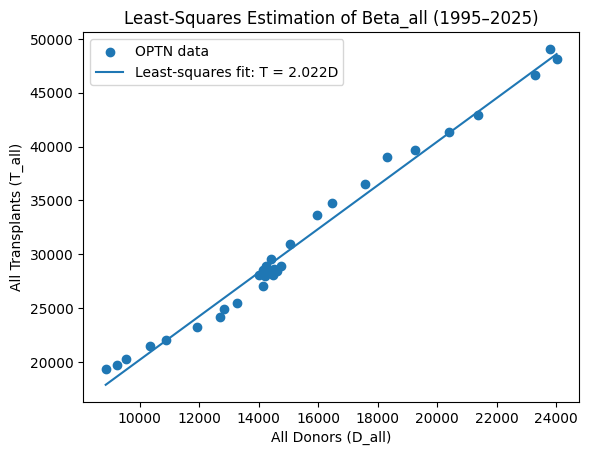

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# -----------------------------
# OPTN DATA: 1995–2025
# -----------------------------

years = np.arange(1995, 2026)

# All donors (D_all)
D_all = np.array([
    8859, 9222, 9546, 10363, 10872, 11942, 12702,
    12821, 13285, 14155, 14497, 14750, 14400, 14207,
    14632, 14504, 14149, 14010, 14258, 14415, 15068,
    15952, 16468, 17570, 19267, 18314, 20404, 21371,
    23291, 24020, 23790
])

# All transplants (T_all)
T_all = np.array([
    19396, 19765, 20316, 21526, 22030, 23274, 24243,
    24916, 25475, 27042, 28119, 28941, 28366, 27967,
    28463, 28668, 28553, 28059, 28956, 29540, 30974,
    33610, 34770, 36530, 39719, 39036, 41356, 42889,
    46634, 48150, 49065
])

# -----------------------------
# LEAST-SQUARES ESTIMATION
# Model: T_all = beta_all * D_all
# -----------------------------

beta_all = np.sum(D_all * T_all) / np.sum(D_all ** 2)

# Predicted transplant values
T_predicted = beta_all * D_all

# -----------------------------
# MODEL ERROR
# -----------------------------

residuals = T_all - T_predicted

MSE = np.mean(residuals ** 2)
RMSE = np.sqrt(MSE)

# R-squared
SS_res = np.sum(residuals ** 2)
SS_tot = np.sum((T_all - np.mean(T_all)) ** 2)

R_squared = 1 - (SS_res / SS_tot)

# -----------------------------
# PRINT RESULTS
# -----------------------------

print("Parameter Estimation Results")
print("----------------------------")
print(f"Years used: 1995–2025")
print(f"Beta_all = {beta_all:.6f}")
print(f"MSE      = {MSE:.2f}")
print(f"RMSE     = {RMSE:.2f}")
print(f"R²       = {R_squared:.4f}")

# -----------------------------
# GRAPH
# -----------------------------

plt.scatter(
    D_all,
    T_all,
    label="OPTN data"
)

# Sort donor values for fitted line
order = np.argsort(D_all)

plt.plot(
    D_all[order],
    T_predicted[order],
    label=f"Least-squares fit: T = {beta_all:.3f}D"
)

plt.xlabel("All Donors (D_all)")
plt.ylabel("All Transplants (T_all)")
plt.title("Least-Squares Estimation of Beta_all (1995–2025)")
plt.legend()
plt.show()